In [1]:
#-------------------------MACHINE LEARNING 

In [2]:
#--------------------------APPRENTISSAGES SUPERVISE 

Le machine learning consiste à :

   " Développer un modèle à partir de données expérimentales "


   - Apprentissage Supervisé
   - Apprentissage Non-Supervisé
   - Apprentissage par renforcement
   - 

In [3]:
#--------------------------APPRENTISSAGES SUPERVISE

la Machine reçoit des données caractérisées par :

- variables x = Features

- Annotées d une variable y = Label / target = objectif



En suite on specifie le Modèle

Entrainement du modèle

In [4]:
#    dataset      ------------------->  Entrainement  ------------------->   Modèle

- 1 Sélectionner un estimateur et préciser ses hyperparamètres:

          model = LinearRegression(--------------------)
- 2 Entrainer le modèle sur les données X,y ( divisées en 2 tableaux Numpy)
 
        model.fit( x, y)

- 3 Evaluer le modèle

        model.score(x,y)

- 4 Utiliser le modèle
      model.predict(x)
  

In [5]:
import numpy as np
import matplotlib.pyplot as plt

1) Regession avec SKLearn

In [6]:
np.random.seed(0)
m = 100    #création 100 samples
x = np.linspace(0, 10, m).reshape(m,1)
y = x + np.random.randn(m, 1)

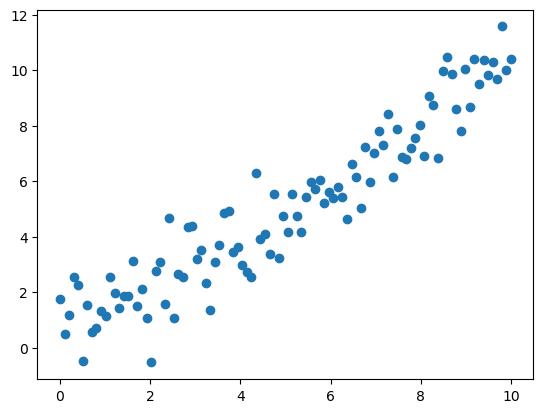

In [7]:
plt.scatter(x, y)

In [8]:
from sklearn.linear_model import LinearRegression 
#from sklearn.svm import  SVR                 ------------------> pour le non linear

In [9]:
model = LinearRegression()
model.fit(x,y)
model.score(x, y)

0.8881140743377214

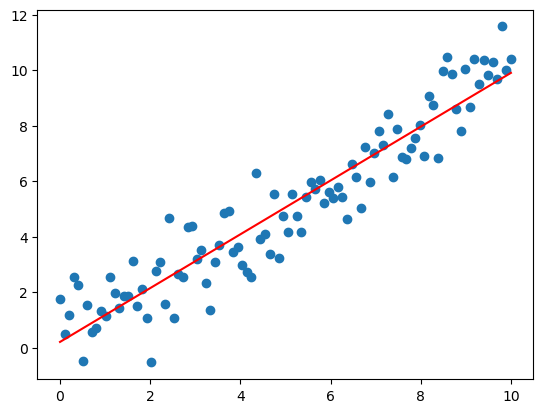

In [12]:
predictions =  model.predict(x)

plt.scatter(x,y)
plt.plot(x, predictions, c='r')



2)  CLASSIFICATIONS

In [1]:
import pandas as pd
import seaborn as sns

In [2]:
titanic = pd.read_csv('titanic.csv')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
titanic = titanic[['survived', 'pclass', 'sex', 'age']]
titanic.dropna(axis=0, inplace=True)
titanic['sex'].replace(['male', 'female'], [0, 1], inplace=True)
titanic.head()

C:\Users\By Etienne\AppData\Local\Temp\ipykernel_2772\3497883788.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['sex'].replace(['male', 'female'], [0, 1], inplace=True)
C:\Users\By Etienne\AppData\Local\Temp\ipykernel_2772\3497883788.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  t

,survived,pclass,sex,age
0,0,3,0,22.0
1,1,1,1,38.0
2,1,3,1,26.0
3,1,1,1,35.0
4,0,3,0,35.0


In [4]:
#------------------ on choisis un modèle Classification

In [5]:
from sklearn.neighbors import KNeighborsClassifier 

In [6]:
model = KNeighborsClassifier ()  #(n_neighbors=5)     0- 10 avec la boocle for

In [7]:
y = titanic['survived']
x = titanic.drop('survived', axis=1)



In [8]:
model.fit(x,y)
model.score(x, y)

0.8417366946778712

In [9]:
#model.predict(x)

In [10]:
def survie(model, pclass=1, sex=0, age=78):
    x = np.array([pclass, sex, age]).reshape(1,3)
    print(model.predict(x))
    print(model.predict_proba(x))

In [11]:
survie(model)

NameError: name 'np' is not defined

In [ ]:
score = []
best_k = 1
best_score = 0

for k in range(best_k, 30):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x,y)
    score.apprend(model.score(x, y))

    if best_score < model.score(x, y):
        best_k = k
        best_score = model.score(x,y)

print(score)
    